# Sales Dashboard & Trend Analyzer project

In [ ]:
# ============================================================
# STEP 0: Import Required Libraries
# numpy  → for mathematical operations and arrays
# pandas → for data loading and manipulation
# matplotlib.pyplot → for creating charts and visualizations
# ============================================================
import numpy as np
import pandas as pd



In [2]:
# ============================================================
# STEP 1: Load the CSV file into a Pandas DataFrame
# pd.read_csv() reads the file and creates a 2D table (DataFrame)
# ============================================================
sales_data=pd.read_csv("sales.csv")

In [3]:
# View first 10 rows to understand the structure of the data
# head(10) returns the first 10 records
sales_data.head(10)

,Date,Product,Category,Region,Units_Sold,Unit_Price,Total_Revenue,Salesperson,Cost_Price
0,2024-01-03,Laptop,Electronics,North,5.0,55000.0,275000.0,Rahul,38000
1,2024-01-05,Mobile Phone,Electronics,South,12.0,18000.0,216000.0,Priya,12000
2,2024-01-07,Office Chair,Furniture,East,NaN,7500.0,60000.0,Amit,4500
3,2024-01-09,Desk,Furniture,West,4.0,12000.0,48000.0,Sneha,7500
4,2024-01-11,Headphones,Electronics,North,20.0,2500.0,50000.0,Rahul,1200
5,2024-01-14,Laptop,Electronics,South,3.0,55000.0,165000.0,Priya,38000
6,2024-01-16,Washing Machine,Appliances,East,6.0,32000.0,192000.0,Amit,22000
7,2024-01-18,Refrigerator,Appliances,West,4.0,45000.0,180000.0,Sneha,30000
8,2024-01-20,Mobile Phone,Electronics,North,15.0,18000.0,270000.0,Rahul,12000
9,2024-01-22,Shirt,Clothing,South,30.0,899.0,26970.0,Priya,350


## Q.1 <B> Use Pandas to handle missing values, rename columns, change data types (Date to datetime)

##### Q.1.A <a> handle missing values

In [4]:
# ============================================================
# Q1.A: Handle Missing Values
# fillna(mean) → replaces NaN (missing) values with
#                the average value of that column
# This is a common technique to avoid data loss
# ============================================================
sales_data["Units_Sold"]=sales_data["Units_Sold"].fillna(sales_data["Units_Sold"].mean())
sales_data["Unit_Price"]=sales_data["Unit_Price"].fillna(sales_data["Unit_Price"].mean())
sales_data["Total_Revenue"]=sales_data["Total_Revenue"].fillna(sales_data["Total_Revenue"].mean())
sales_data["Cost_Price"]=sales_data["Cost_Price"].fillna(sales_data["Cost_Price"].mean())


In [5]:
sales_data.head(10)

,Date,Product,Category,Region,Units_Sold,Unit_Price,Total_Revenue,Salesperson,Cost_Price
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.0,275000.0,Rahul,38000
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.0,216000.0,Priya,12000
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.0,60000.0,Amit,4500
3,2024-01-09,Desk,Furniture,West,4.000000,12000.0,48000.0,Sneha,7500
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.0,50000.0,Rahul,1200
5,2024-01-14,Laptop,Electronics,South,3.000000,55000.0,165000.0,Priya,38000
6,2024-01-16,Washing Machine,Appliances,East,6.000000,32000.0,192000.0,Amit,22000
7,2024-01-18,Refrigerator,Appliances,West,4.000000,45000.0,180000.0,Sneha,30000
8,2024-01-20,Mobile Phone,Electronics,North,15.000000,18000.0,270000.0,Rahul,12000
9,2024-01-22,Shirt,Clothing,South,30.000000,899.0,26970.0,Priya,350


#### Q.1.B <a> rename columns

In [6]:
# ============================================================
# Q1.B: Rename Columns
# rename(columns={old_name: new_name}) → renames specific columns
# inplace=True → modifies the original DataFrame directly
# ============================================================
sales_data.rename(columns={
    "Date":"Sales_Date",
    "Units_Sold":"Quantity",
    "Unit_Price":"Price_Per_Unit",
    "Salesperson":"Agent_Name"
},inplace=True)


In [7]:
sales_data

,Sales_Date,Product,Category,Region,Quantity,Price_Per_Unit,Total_Revenue,Agent_Name,Cost_Price
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.0,275000.0,Rahul,38000
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.0,216000.0,Priya,12000
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.0,60000.0,Amit,4500
3,2024-01-09,Desk,Furniture,West,4.000000,12000.0,48000.0,Sneha,7500
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.0,50000.0,Rahul,1200
...,...,...,...,...,...,...,...,...,...
128,2024-12-19,Refrigerator,Appliances,North,20.000000,45000.0,900000.0,Rahul,30000
129,2024-12-22,Washing Machine,Appliances,South,25.000000,32000.0,800000.0,Priya,22000
130,2024-12-25,Laptop,Electronics,East,40.000000,55000.0,2200000.0,Amit,38000
131,2024-12-28,Mobile Phone,Electronics,West,88.000000,18000.0,1584000.0,Sneha,12000


#### Q.1.C <a> change data types

In [8]:
pd.to_datetime(sales_data["Sales_Date"])

0     2024-01-03
1     2024-01-05
2     2024-01-07
3     2024-01-09
4     2024-01-11
         ...    
128   2024-12-19
129   2024-12-22
130   2024-12-25
131   2024-12-28
132   2024-12-30
Name: Sales_Date, Length: 133, dtype: datetime64[ns]

In [9]:
sales_data.dtypes

Sales_Date         object
Product            object
Category           object
Region             object
Quantity          float64
Price_Per_Unit    float64
Total_Revenue     float64
Agent_Name         object
Cost_Price          int64
dtype: object

In [10]:
# ============================================================
# Q1.C: Change Data Types
#
# Method 1: Convert Cost_Price from int to float64
# astype(np.float64) → changes the column's data type
# np.float64 is a NumPy 64-bit floating point number
# ============================================================
sales_data["Cost_Price"]=sales_data["Cost_Price"].astype(np.float64)

In [11]:
sales_data

,Sales_Date,Product,Category,Region,Quantity,Price_Per_Unit,Total_Revenue,Agent_Name,Cost_Price
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.0,275000.0,Rahul,38000.0
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.0,216000.0,Priya,12000.0
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.0,60000.0,Amit,4500.0
3,2024-01-09,Desk,Furniture,West,4.000000,12000.0,48000.0,Sneha,7500.0
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.0,50000.0,Rahul,1200.0
...,...,...,...,...,...,...,...,...,...
128,2024-12-19,Refrigerator,Appliances,North,20.000000,45000.0,900000.0,Rahul,30000.0
129,2024-12-22,Washing Machine,Appliances,South,25.000000,32000.0,800000.0,Priya,22000.0
130,2024-12-25,Laptop,Electronics,East,40.000000,55000.0,2200000.0,Amit,38000.0
131,2024-12-28,Mobile Phone,Electronics,West,88.000000,18000.0,1584000.0,Sneha,12000.0


In [12]:
# ============================================================
# Method 2: Convert Sales_Date from string (object) to datetime
# pd.to_datetime() → converts text dates into proper date objects
# This allows us to extract Month, Quarter, Year from dates
# Must assign back with = to save the change in the DataFrame
# ============================================================ 

sales_data["Sales_Date"]=pd.to_datetime(sales_data["Sales_Date"])

In [13]:
sales_data

,Sales_Date,Product,Category,Region,Quantity,Price_Per_Unit,Total_Revenue,Agent_Name,Cost_Price
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.0,275000.0,Rahul,38000.0
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.0,216000.0,Priya,12000.0
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.0,60000.0,Amit,4500.0
3,2024-01-09,Desk,Furniture,West,4.000000,12000.0,48000.0,Sneha,7500.0
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.0,50000.0,Rahul,1200.0
...,...,...,...,...,...,...,...,...,...
128,2024-12-19,Refrigerator,Appliances,North,20.000000,45000.0,900000.0,Rahul,30000.0
129,2024-12-22,Washing Machine,Appliances,South,25.000000,32000.0,800000.0,Priya,22000.0
130,2024-12-25,Laptop,Electronics,East,40.000000,55000.0,2200000.0,Amit,38000.0
131,2024-12-28,Mobile Phone,Electronics,West,88.000000,18000.0,1584000.0,Sneha,12000.0


In [14]:
sales_data.dtypes

Sales_Date        datetime64[ns]
Product                   object
Category                  object
Region                    object
Quantity                 float64
Price_Per_Unit           float64
Total_Revenue            float64
Agent_Name                object
Cost_Price               float64
dtype: object

## <b> Q.2 Use NumPy for statistical analysis — mean, std, variance of revenue

In [15]:
# ============================================================
# Q2: NumPy Statistical Analysis on Total_Revenue column
#
# np.mean()   → calculates the average value
# np.std()    → calculates standard deviation (spread of data)
# np.var()    → calculates variance (std squared)
#
# f-string (f"...") → used to embed variable values in strings
# ============================================================

sales_data_mean=np.mean(sales_data["Total_Revenue"])
sales_data_std=np.std(sales_data["Total_Revenue"])
sales_data_variance=np.var(sales_data["Total_Revenue"])



print(f"The mean of sales_data column is :{sales_data_mean}")
print(f"The std of sales_data column is :{sales_data_std}")
print(f"The variance of sales_data column is :{sales_data_variance}")

The mean of sales_data column is :439251.8702290076
The std of sales_data column is :420833.3595559694
The variance of sales_data column is :177100716515.16385


## <b>Q.3 Add columns: Month, Quarter, Profit_Margin using .apply() and lambda

### <a>Q.3.(1 and 2) Add (Month and Quarter) New Columns using .apply() and lambda

In [16]:
# ============================================================
# Q3: Add New Columns using .apply() and lambda
#
# .apply(lambda x: ...) → applies a function to every row/value
# lambda x: x.month    → extracts the month number (1–12)
# lambda x: x.quarter  → extracts the quarter number (1–4)
#
# FIX: Use apply() + lambda as required by the question
# ============================================================
sales_data["Month"]   = sales_data["Sales_Date"].apply(lambda x: x.month)
sales_data["Quarter"] = sales_data["Sales_Date"].apply(lambda x: x.quarter)


In [17]:
sales_data

,Sales_Date,Product,Category,Region,Quantity,Price_Per_Unit,Total_Revenue,Agent_Name,Cost_Price,Month,Quarter
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.0,275000.0,Rahul,38000.0,1,1
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.0,216000.0,Priya,12000.0,1,1
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.0,60000.0,Amit,4500.0,1,1
3,2024-01-09,Desk,Furniture,West,4.000000,12000.0,48000.0,Sneha,7500.0,1,1
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.0,50000.0,Rahul,1200.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
128,2024-12-19,Refrigerator,Appliances,North,20.000000,45000.0,900000.0,Rahul,30000.0,12,4
129,2024-12-22,Washing Machine,Appliances,South,25.000000,32000.0,800000.0,Priya,22000.0,12,4
130,2024-12-25,Laptop,Electronics,East,40.000000,55000.0,2200000.0,Amit,38000.0,12,4
131,2024-12-28,Mobile Phone,Electronics,West,88.000000,18000.0,1584000.0,Sneha,12000.0,12,4


### <a>Q.3.3 Add profit_Margin New Columns using .apply() and lambda

In [18]:
# ============================================================
# Profit_Margin column — 3 methods shown below
# Formula: ((Revenue - Cost) / Revenue) * 100
# Method shown below uses apply() + lambda (best for this task)
# ============================================================

# Method 1 (commented out — direct vectorized calculation):
# sales_data["Profit_Margin"] = ((sales_data["Total_Revenue"] -
#     (sales_data["Quantity"] * sales_data["Cost_Price"])) * 100) / sales_data["Total_Revenue"]

# Method 2 (commented out — custom function + apply):
# def profit_margin_fun(row):
#     return ((row["Total_Revenue"] - (row["Quantity"] * row["Cost_Price"])) * 100) / row["Total_Revenue"]
# sales_data["Profit_Margin"] = sales_data.apply(profit_margin_fun, axis=1)

# Method 3 (USED — lambda + apply):
# axis=1 means apply row-by-row (across columns, not down rows)


sales_data["Profit_Margin"]=sales_data.apply(lambda row:(((row["Total_Revenue"]-(row["Quantity"]*row["Cost_Price"]))*100)/row["Total_Revenue"]),axis=1,)


In [19]:

sales_data.head(50)

,Sales_Date,Product,Category,Region,Quantity,Price_Per_Unit,Total_Revenue,Agent_Name,Cost_Price,Month,Quarter,Profit_Margin
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.000000,275000.000000,Rahul,38000.0,1,1,30.909091
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.000000,216000.000000,Priya,12000.0,1,1,33.333333
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.000000,60000.000000,Amit,4500.0,1,1,-184.026718
3,2024-01-09,Desk,Furniture,West,4.000000,12000.000000,48000.000000,Sneha,7500.0,1,1,37.500000
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.000000,50000.000000,Rahul,1200.0,1,1,52.000000
5,2024-01-14,Laptop,Electronics,South,3.000000,55000.000000,165000.000000,Priya,38000.0,1,1,30.909091
6,2024-01-16,Washing Machine,Appliances,East,6.000000,32000.000000,192000.000000,Amit,22000.0,1,1,31.250000
7,2024-01-18,Refrigerator,Appliances,West,4.000000,45000.000000,180000.000000,Sneha,30000.0,1,1,33.333333
8,2024-01-20,Mobile Phone,Electronics,North,15.000000,18000.000000,270000.000000,Rahul,12000.0,1,1,33.333333
9,2024-01-22,Shirt,Clothing,South,30.000000,899.000000,26970.000000,Priya,350.0,1,1,61.067853


## <b> Q.4 Use Matplotlib to plot:

## <b> Q.4.1 Bar chart → Total revenue by product category
## <b> Q.4.2 Line plot → Monthly sales trend over the year
## <b> Q.4.3 Pie chart → Region-wise revenue share (North/South/East/West)
## <b> Q.4.4 Histogram → Revenue distribution across all transactions

### <a>Q.4.1 Bar Chart — Total Revenue by Category

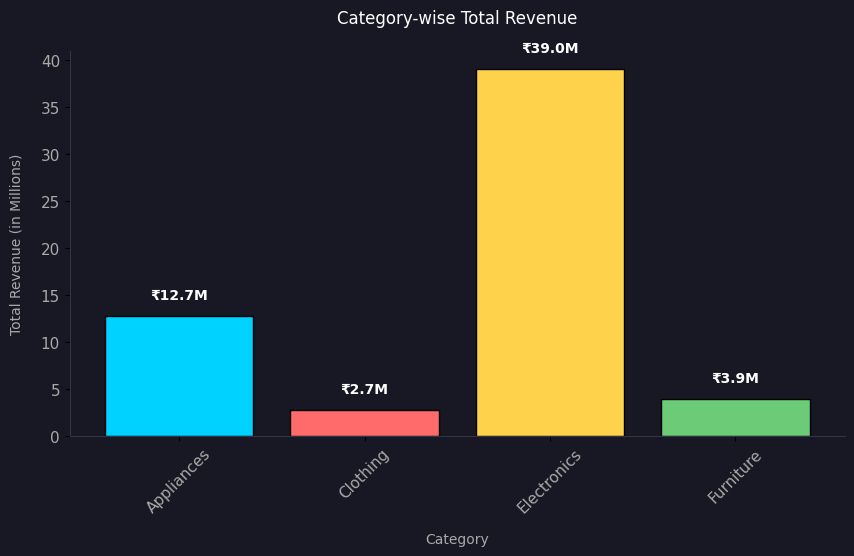

In [ ]:
# ============================================================
# CHART 1: Bar Chart — Total Revenue by Category
# groupby("Category") → groups all rows by product category
# ["Total_Revenue"].sum() → adds up revenue for each category
# reset_index() → converts the result back to a normal DataFrame
# ============================================================
import matplotlib.pyplot as plt


grouped=sales_data.groupby("Category")["Total_Revenue"].sum().reset_index()
x_axis=grouped["Category"]
y_axis=grouped["Total_Revenue"]/100_00_00

fig,ax=plt.subplots(figsize=(10,5))
fig.patch.set_facecolor("#181824")
ax.set_facecolor("#181824")
ax.bar(x_axis,y_axis,color=["#00D2FF", "#FF6B6B", "#FFD24C", "#6BCB77"],edgecolor="black")
ax.set_title("Category-wise Total Revenue",pad=20,color="white")
ax.set_xlabel("Category",labelpad=12,color="darkgray")
ax.set_ylabel("Total Revenue (in Millions)",labelpad=12,color="darkgray")
plt.xticks(rotation=45,color="darkgray",fontsize=11)
plt.yticks(color="darkgray",fontsize=11)
for x, y in zip(x_axis, y_axis):
    ax.annotate(
        f"₹{y:.1f}M",
        xy=(x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="white",
        weight="bold",
    )
    for spine in ["top", "right"]:
       ax.spines[spine].set_visible(False)
    for spine in ["left","bottom"]:
        ax.spines[spine].set_color("#333345")

plt.show()

In [21]:
grouped

,Category,Total_Revenue
0,Appliances,1.272800e+07
1,Clothing,2.748747e+06
2,Electronics,3.900325e+07
3,Furniture,3.940500e+06


### <a>Q.4.2 Line Plot — Monthly Sales Trend

In [ ]:

grouped_sales=sales_data.groupby(sales_data["Month"])["Total_Revenue"].sum().reset_index()

In [23]:
grouped_sales

,Month,Total_Revenue
0,1,2.307222e+06
1,2,2.030410e+06
2,3,2.611895e+06
3,4,3.470875e+06
4,5,4.278855e+06
5,6,4.500840e+06
6,7,4.559572e+06
7,8,4.670805e+06
8,9,5.103790e+06
9,10,6.806775e+06


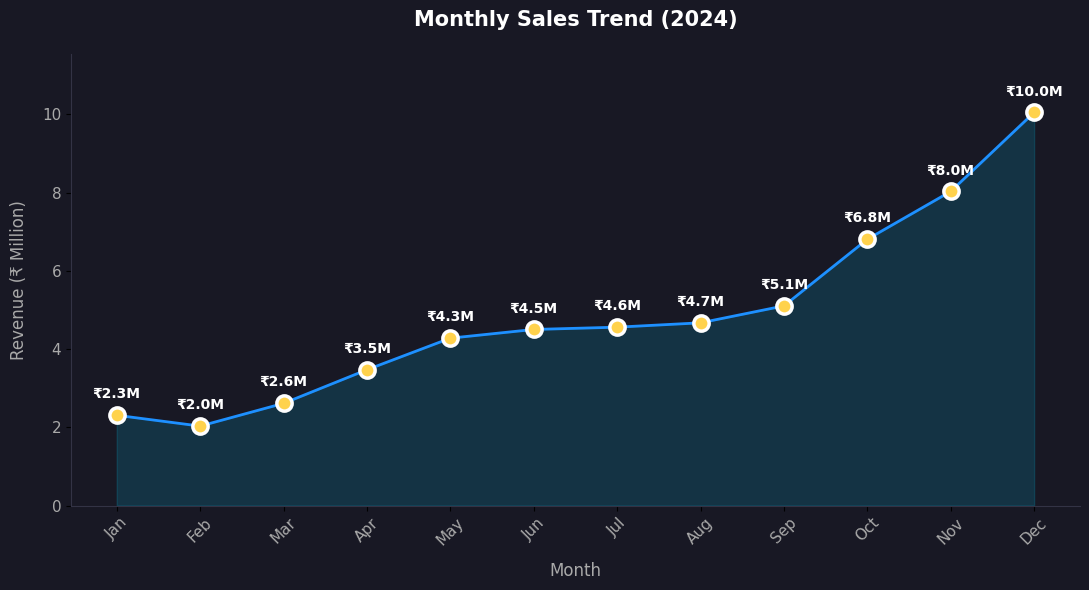

In [ ]:
# ============================================================
# CHART 2: Line Plot — Monthly Sales Trend
# groupby(Month) → groups data by month number
# month_map → dictionary to convert 1,2,3... → Jan,Feb,Mar...
# fill_between() → adds shaded area under the line
# ============================================================

month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}
grouped_sales["Month_Name"] = grouped_sales["Month"].map(month_map)

x_axis=grouped_sales["Month_Name"]
y_axis=grouped_sales["Total_Revenue"]/100_00_00

fig,ax=plt.subplots(figsize=(11,6))
fig.patch.set_facecolor("#181824")
ax.set_facecolor("#181824")
ax.plot(x_axis,y_axis,color="dodgerblue",marker="o",linewidth=2,markersize=11,markerfacecolor="#FFD24C",markeredgecolor="white",markeredgewidth=2.5,zorder=3,)
ax.fill_between(x_axis,y_axis,color="#00D2FF",alpha=0.15, zorder=2)
ax.set_title("Monthly Sales Trend (2024)", color="white", fontsize=15, weight="bold", pad=20)
ax.set_ylabel("Revenue (₹ Million)", color="darkgray", fontsize=12, labelpad=10)
ax.set_xlabel("Month", color="darkgray", fontsize=12, labelpad=10)


for x, y in zip(x_axis, y_axis):
    ax.annotate(
        f"₹{y:.1f}M",
        xy=(x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="white",
        weight="bold",
    )
    for spine in ["top", "right"]:
       ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
       ax.spines[spine].set_color("#333345")
    plt.xticks(rotation=45,color="darkgray",fontsize=11)
    plt.yticks(color="darkgray",fontsize=11)
    ax.set_ylim(0, max(y_axis) + 1.5)
    plt.tight_layout()

plt.show()

In [25]:
sales_data.head(10)

,Sales_Date,Product,Category,Region,Quantity,Price_Per_Unit,Total_Revenue,Agent_Name,Cost_Price,Month,Quarter,Profit_Margin
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.0,275000.0,Rahul,38000.0,1,1,30.909091
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.0,216000.0,Priya,12000.0,1,1,33.333333
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.0,60000.0,Amit,4500.0,1,1,-184.026718
3,2024-01-09,Desk,Furniture,West,4.000000,12000.0,48000.0,Sneha,7500.0,1,1,37.500000
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.0,50000.0,Rahul,1200.0,1,1,52.000000
5,2024-01-14,Laptop,Electronics,South,3.000000,55000.0,165000.0,Priya,38000.0,1,1,30.909091
6,2024-01-16,Washing Machine,Appliances,East,6.000000,32000.0,192000.0,Amit,22000.0,1,1,31.250000
7,2024-01-18,Refrigerator,Appliances,West,4.000000,45000.0,180000.0,Sneha,30000.0,1,1,33.333333
8,2024-01-20,Mobile Phone,Electronics,North,15.000000,18000.0,270000.0,Rahul,12000.0,1,1,33.333333
9,2024-01-22,Shirt,Clothing,South,30.000000,899.0,26970.0,Priya,350.0,1,1,61.067853


## <a> Q.4.3 Pie Chart — Region-wise Revenue Share

In [26]:
grouped_Region=sales_data.groupby("Region")["Total_Revenue"].sum().reset_index()

In [27]:
grouped_Region

,Region,Total_Revenue
0,East,1.504726e+07
1,North,1.506847e+07
2,South,1.580712e+07
3,West,1.249765e+07


Text(0.5, 1.0, 'Region-wise Revenue Share')

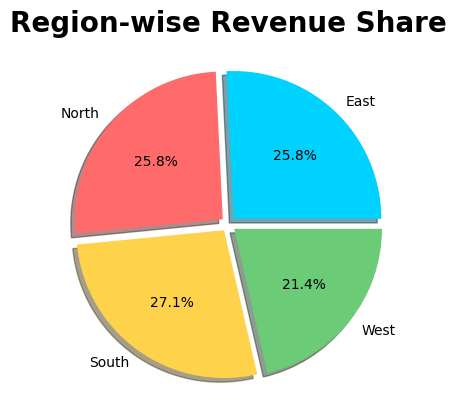

In [ ]:
# ============================================================
# CHART 3: Pie Chart — Region-wise Revenue Share
# groupby("Region") → groups data by region
# explode → separates each slice slightly from the center
# autopct → shows percentage labels on each slice
# shadow=True → adds a shadow effect
# ============================================================
x_axis=grouped_Region["Region"]
y_axis=grouped_Region["Total_Revenue"]

color_cullaction=["#00D2FF", "#FF6B6B", "#FFD24C", "#6BCB77"]
explodes=[0.05,0.05,0.05,0.05]

plt.pie(y_axis,labels=x_axis,colors=color_cullaction,explode=explodes,autopct="%1.1f%%",shadow=True)
plt.title("Region-wise Revenue Share",fontsize=20,weight="bold")

In [29]:
sales_data

,Sales_Date,Product,Category,Region,Quantity,Price_Per_Unit,Total_Revenue,Agent_Name,Cost_Price,Month,Quarter,Profit_Margin
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.0,275000.0,Rahul,38000.0,1,1,30.909091
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.0,216000.0,Priya,12000.0,1,1,33.333333
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.0,60000.0,Amit,4500.0,1,1,-184.026718
3,2024-01-09,Desk,Furniture,West,4.000000,12000.0,48000.0,Sneha,7500.0,1,1,37.500000
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.0,50000.0,Rahul,1200.0,1,1,52.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
128,2024-12-19,Refrigerator,Appliances,North,20.000000,45000.0,900000.0,Rahul,30000.0,12,4,33.333333
129,2024-12-22,Washing Machine,Appliances,South,25.000000,32000.0,800000.0,Priya,22000.0,12,4,31.250000
130,2024-12-25,Laptop,Electronics,East,40.000000,55000.0,2200000.0,Amit,38000.0,12,4,30.909091
131,2024-12-28,Mobile Phone,Electronics,West,88.000000,18000.0,1584000.0,Sneha,12000.0,12,4,33.333333


## <a> Q.4.4 Histogram — Revenue Distribution

Text(0.5, 1.0, 'Revenue Distribution Across All Transactions')

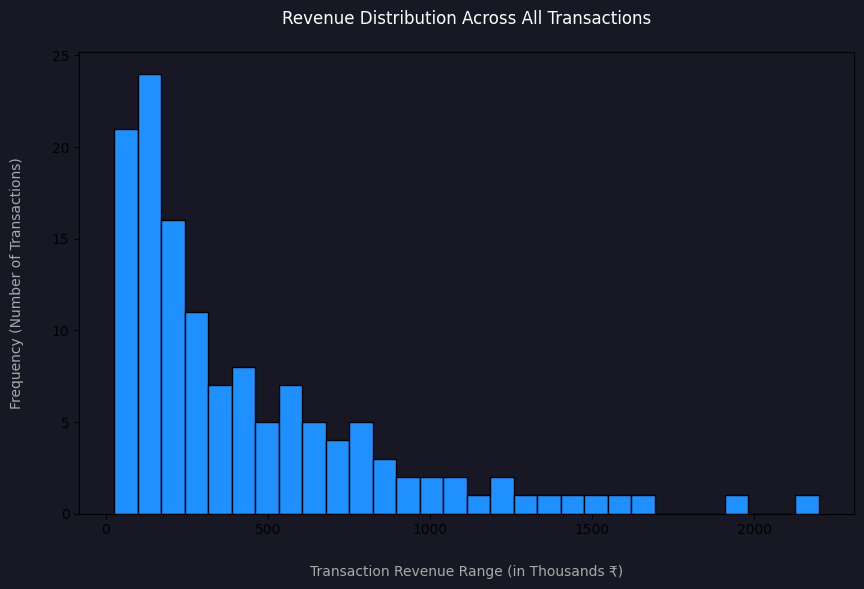

In [ ]:
# ============================================================
# CHART 5: Histogram — Revenue Distribution
# Histogram shows HOW MANY transactions fall in each
# revenue range (bin)
# bins=25 → divides data into 25 equal ranges
# ============================================================
y_axis=sales_data["Total_Revenue"]/1000
fig,ax=plt.subplots(figsize=(10,6))
ax.hist(y_axis,bins=30,edgecolor="Black",color="dodgerblue")
fig.patch.set_facecolor("#181824")
ax.set_facecolor("#181824")
ax.set_xlabel("Transaction Revenue Range (in Thousands ₹)",labelpad=20,color="darkgray")
ax.set_ylabel("Frequency (Number of Transactions)",labelpad=20,color="darkgray")
ax.set_title("Revenue Distribution Across All Transactions",pad=20,color="White")



In [31]:
sales_data

,Sales_Date,Product,Category,Region,Quantity,Price_Per_Unit,Total_Revenue,Agent_Name,Cost_Price,Month,Quarter,Profit_Margin
0,2024-01-03,Laptop,Electronics,North,5.000000,55000.0,275000.0,Rahul,38000.0,1,1,30.909091
1,2024-01-05,Mobile Phone,Electronics,South,12.000000,18000.0,216000.0,Priya,12000.0,1,1,33.333333
2,2024-01-07,Office Chair,Furniture,East,37.870229,7500.0,60000.0,Amit,4500.0,1,1,-184.026718
3,2024-01-09,Desk,Furniture,West,4.000000,12000.0,48000.0,Sneha,7500.0,1,1,37.500000
4,2024-01-11,Headphones,Electronics,North,20.000000,2500.0,50000.0,Rahul,1200.0,1,1,52.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
128,2024-12-19,Refrigerator,Appliances,North,20.000000,45000.0,900000.0,Rahul,30000.0,12,4,33.333333
129,2024-12-22,Washing Machine,Appliances,South,25.000000,32000.0,800000.0,Priya,22000.0,12,4,31.250000
130,2024-12-25,Laptop,Electronics,East,40.000000,55000.0,2200000.0,Amit,38000.0,12,4,30.909091
131,2024-12-28,Mobile Phone,Electronics,West,88.000000,18000.0,1584000.0,Sneha,12000.0,12,4,33.333333


## <b> Q.5 Use groupby() with multiple columns (Product + Region) and apply sum(), mean(), count() together using .agg()

In [32]:
### question second last 
sales_data.groupby(["Product","Region"])["Total_Revenue"].agg(["sum","mean","count"]).reset_index()

,Product,Region,sum,mean,count
0,Desk,East,2.160000e+05,2.160000e+05,1
1,Desk,North,6.480000e+05,1.620000e+05,4
2,Desk,South,3.480000e+05,1.740000e+05,2
3,Desk,West,7.560000e+05,1.512000e+05,5
4,Headphones,East,4.450000e+05,1.483333e+05,3
5,Headphones,North,7.625000e+05,1.525000e+05,5
6,Headphones,South,5.125000e+05,1.708333e+05,3
7,Headphones,West,4.250000e+05,1.416667e+05,3
8,Jeans,East,5.741619e+05,2.870809e+05,2
9,Jeans,North,3.447700e+05,1.149233e+05,3


## <b> Q.6 Merge two dataframes (Sales + Product Info) using pd.merge() with inner join

In [33]:
product_sales=pd.read_csv("Product info.csv")
sales=pd.read_csv("sales.csv")
pd.merge(product_sales,sales,on="Product",how="inner")

,Product,Brand,Warranty_Years,Rating,Launch_Year,Date,Category,Region,Units_Sold,Unit_Price,Total_Revenue,Salesperson,Cost_Price
0,Laptop,Dell,2,4.5,2022,2024-01-03,Electronics,North,5.0,55000.0,275000.0,Rahul,38000
1,Laptop,Dell,2,4.5,2022,2024-01-14,Electronics,South,3.0,55000.0,165000.0,Priya,38000
2,Laptop,Dell,2,4.5,2022,2024-01-28,Electronics,West,7.0,55000.0,385000.0,Sneha,38000
3,Laptop,Dell,2,4.5,2022,2024-02-19,Electronics,North,6.0,55000.0,330000.0,Rahul,38000
4,Laptop,Dell,2,4.5,2022,2024-03-13,Electronics,South,9.0,55000.0,495000.0,Priya,38000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,Jeans,Levi's,0,4.1,2022,2024-08-05,Clothing,West,85.0,1499.0,127415.0,Sneha,600
129,Jeans,Levi's,0,4.1,2022,2024-09-08,Clothing,East,90.0,1499.0,134910.0,Amit,600
130,Jeans,Levi's,0,4.1,2022,2024-10-11,Clothing,South,95.0,1499.0,142405.0,Priya,600
131,Jeans,Levi's,0,4.1,2022,2024-11-13,Clothing,North,105.0,1499.0,157395.0,Rahul,600
